<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week11/day3-4/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.utils import to_categorical

In [4]:
num_words = 10_000  # keep the 10k most frequent tokens

(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

In [5]:
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results

In [6]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [7]:
x_val = x_train[:10000]
x_train_final = x_train[10000:]

y_val = y_train[:10000]
y_train_final = y_train[10000:]

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(x_train_final, y_train_final,
                     epochs=20,
                     batch_size=512,
                     validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.7712 - loss: 0.5370 - val_accuracy: 0.8634 - val_loss: 0.3985
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.8915 - loss: 0.3275 - val_accuracy: 0.8780 - val_loss: 0.3192
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9163 - loss: 0.2451 - val_accuracy: 0.8813 - val_loss: 0.3003
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9357 - loss: 0.1953 - val_accuracy: 0.8890 - val_loss: 0.2769
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9466 - loss: 0.1644 - val_accuracy: 0.8855 - val_loss: 0.2944
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9553 - loss: 0.1397 - val_accuracy: 0.8871 - val_loss: 0.2855
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9623 - loss: 0.1190 - val_accuracy: 0.8791 - val_loss: 0.3055
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9700 - loss: 0.0997 - val_accuracy: 0.8530 - 

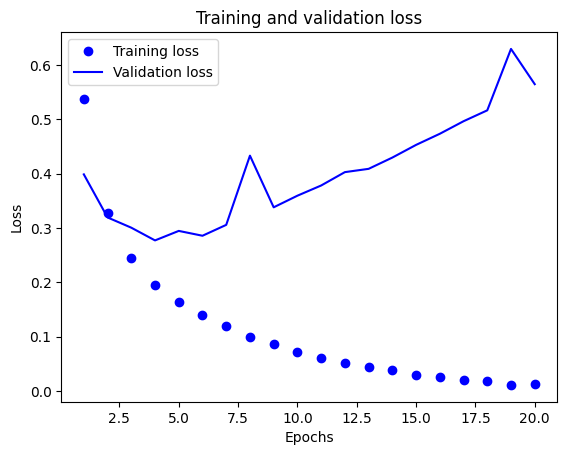

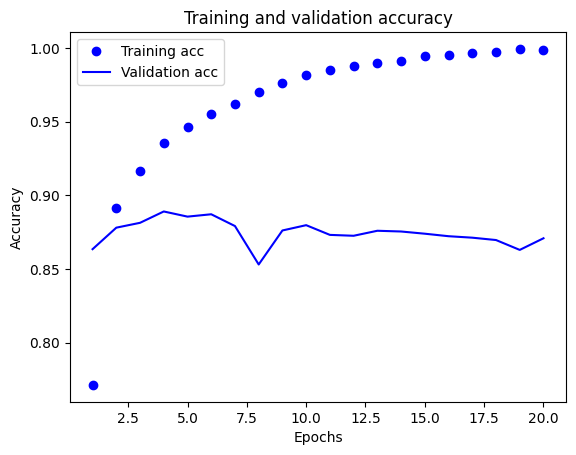

In [10]:
import matplotlib.pyplot as plt

history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.figure()
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.figure()
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [11]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                     epochs=4,
                     batch_size=512)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8178 - loss: 0.4526
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9038 - loss: 0.2648
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9232 - loss: 0.2102
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9364 - loss: 0.1759


In [12]:
results = model.evaluate(x_test, y_test)
print(f"Test loss: {results[0]:.4f}")
print(f"Test accuracy: {results[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8856 - loss: 0.2876
Test loss: 0.2876
Test accuracy: 0.8856



```markdown
## Conclusion

### Observations on Training vs. Validation Performance

Plotting loss and accuracy across epochs revealed a clear overfitting pattern:

- **Training loss** decreased steadily across all 20 epochs, approaching near-zero, while
  **training accuracy** climbed toward ~99.9%.
- **Validation loss** bottomed out around **epoch 4** (~0.28) and then trended upward for
  the remainder of training, with a sharp spike from epoch 8 onward.
- **Validation accuracy** peaked around epoch 4 (~88.9%) and then plateaued/declined, while
  training accuracy kept rising.

This growing gap between training and validation performance is the fingerprint of
**overfitting**: the model had enough capacity to memorize the training set rather than
generalize. The optimal stopping point was **epoch 4**, right before validation loss
started climbing — so the model was retrained from scratch on the full training set for
4 epochs and evaluated on the held-out test set.

### Final Results

- **Test loss:** 0.2876
- **Test accuracy:** 88.56%

This result closely matches the validation performance observed at epoch 4 (~0.28 loss,
~88.9% accuracy), suggesting the validation set was a good proxy for test-set performance
and that 4 epochs was a reasonable stopping point.

### Key Takeaways

- The model uses one-hot encoded (bag-of-words style) input, meaning it has no sense of
  word order — this caps the achievable accuracy for this architecture.
- ~88-89% accuracy is a reasonable result for a simple Dense network on IMDB sentiment
  classification. More advanced approaches (word embeddings, RNNs, CNNs, or transformers)
  typically push accuracy into the low-to-mid 90s by capturing sequential/contextual
  information that this model discards.
- This project demonstrates the core workflow for text classification: preprocessing
  text into numerical form, designing a simple network, and using validation curves to
  guard against overfitting — a foundation for more advanced NLP tasks like sentiment
  analysis and sequence modeling.
```